In [12]:
%pip install nba_api
%pip install seaborn
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.9 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/8.9 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.9 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.9 MB 2.1 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.9 MB 2.3 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.9 MB 2.5 MB/s eta 0:00:03
   --------------------- ------------------ 4.7/8.9 MB 2.7 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/8.9 MB 2.7 MB/s eta 0:00:02
   ---------------------------- ----------- 6.

Agrupación de jugadores por esitlo de juego (Clustering)

In [5]:
# 1.1: Importación de Librerías y Obtención de Datos
import pandas as pd
import numpy as np
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Desactivar advertencias de valores futuros en seaborn y pandas
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Obtener estadísticas de todos los jugadores de la temporada regular actual
try:
    player_stats = leaguedashplayerstats.LeagueDashPlayerStats(season='2023-24', season_type_all_star='Regular Season').get_data_frames()[0]
    print("Datos obtenidos correctamente.")
except Exception as e:
    print(f"Error al obtener los datos: {e}")

Datos obtenidos correctamente.


In [6]:
#1.2: Preprocesamiento y Creación del DataFrame

# Filtraremos jugadores con pocos minutos para evitar ruido. Luego, seleccionaremos
# características relevantes que definan un estilo de juego y las normalizaremos
# "por 36 minutos" para poder comparar jugadores de manera justa.

# Filtrar jugadores con al menos 500 minutos jugados en la temporada
filtered_players = player_stats[player_stats['MIN'] >= 500].copy()

# Seleccionar las estadísticas que definen el estilo de juego
stats_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 'TOV']
info_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'MIN']

# Crear el DataFrame para el modelo
model_df = filtered_players[info_cols + stats_cols].copy()

# Normalizar estadísticas por 36 minutos
for col in stats_cols:
    if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']:
        model_df[col + '_PER36'] = (model_df[col] / model_df['MIN']) * 36

# Llenar posibles valores nulos (e.g., si un jugador no ha tirado triples)
model_df.fillna(0, inplace=True)

# Seleccionar columnas finales para el modelo
features_per36 = [col + '_PER36' for col in stats_cols if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']]
final_features = features_per36 + ['FG_PCT', 'FG3_PCT', 'FT_PCT']

X = model_df[final_features]

print("DataFrame para el modelo de clustering (primeras 5 filas):")
print(model_df.head())

DataFrame para el modelo de clustering (primeras 5 filas):
     PLAYER_NAME TEAM_ABBREVIATION          MIN   PTS  REB  AST  STL  BLK  \
1       AJ Green               MIL   614.281667   252   64   30    9    4   
3   Aaron Gordon               DEN  2296.810000  1013  471  259   56   45   
4  Aaron Holiday               HOU  1269.296667   514  123  140   42    6   
5  Aaron Nesmith               IND  1994.655000   877  275  108   65   49   
6  Aaron Wiggins               OKC  1227.938333   542  186   86   56   19   

   FGA  FG_PCT  FG3A  FG3_PCT  FTA  FT_PCT  TOV  PTS_PER36  REB_PER36  \
1  196   0.423   169    0.408   19   0.895   12  14.768469   3.750722   
3  716   0.556   138    0.290  269   0.658  105  15.877674   7.382413   
4  417   0.446   217    0.387   63   0.921   53  14.578152   3.488546   
5  635   0.496   334    0.419  137   0.781   64  15.828301   4.963264   
6  377   0.562   126    0.492   71   0.789   56  15.890049   5.453043   

   AST_PER36  STL_PER36  BLK_PER36  FGA

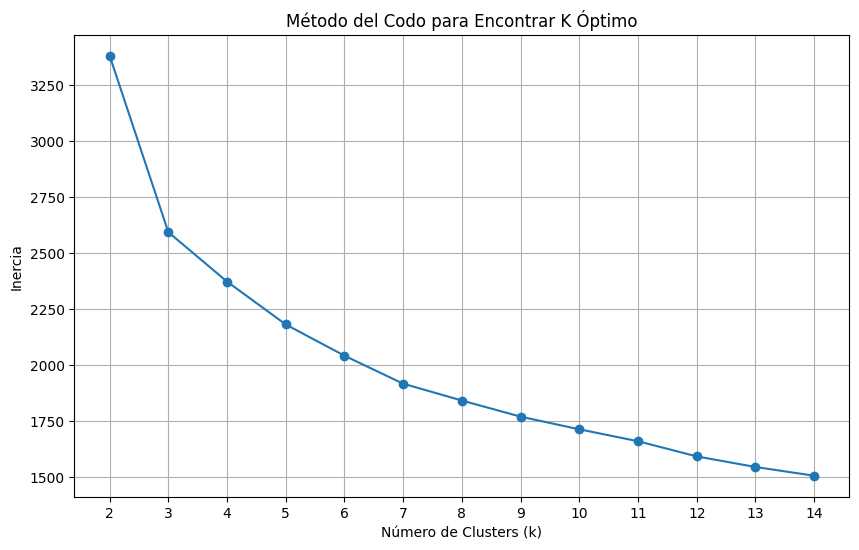

In [7]:
#1.3: Encontrar el Número Óptimo de Clusters (Método del Codo)

# Escalar los datos es crucial para K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcular la inercia para diferentes valores de k
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [8]:
#1.4: Aplicar K-Means y Analizar los Clusters
# Basado en el gráfico del codo, elegiremos un valor para `k` (usualmente
# donde la curva se "aplana"). Un valor entre 5 y 7 parece razonable. Usemos `k=6`.

optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Añadir la etiqueta del cluster al DataFrame
model_df['CLUSTER'] = clusters

# Analizar las características promedio de cada cluster
cluster_analysis = model_df[final_features + ['CLUSTER']].groupby('CLUSTER').mean().round(2)

print(f"Análisis de los {optimal_k} clusters encontrados:")
print(cluster_analysis)

Análisis de los 6 clusters encontrados:
         PTS_PER36  REB_PER36  AST_PER36  STL_PER36  BLK_PER36  FGA_PER36  \
CLUSTER                                                                     
0            16.42       4.92       2.90       0.98       0.44      13.38   
1            17.26      10.32       2.84       0.98       1.54      12.70   
2            23.53       5.83       5.76       1.12       0.56      17.88   
3            11.59       5.87       2.82       1.18       0.69       9.58   
4            13.46      11.67       2.27       0.97       1.75       8.81   
5            13.55       4.82       6.47       1.67       0.50      11.41   

         FG3A_PER36  FTA_PER36  TOV_PER36  FG_PCT  FG3_PCT  FT_PCT  
CLUSTER                                                             
0              7.47       2.35       1.49    0.44     0.37    0.83  
1              3.00       3.64       1.99    0.53     0.36    0.75  
2              6.34       5.25       2.71    0.47     0.36    0.82 

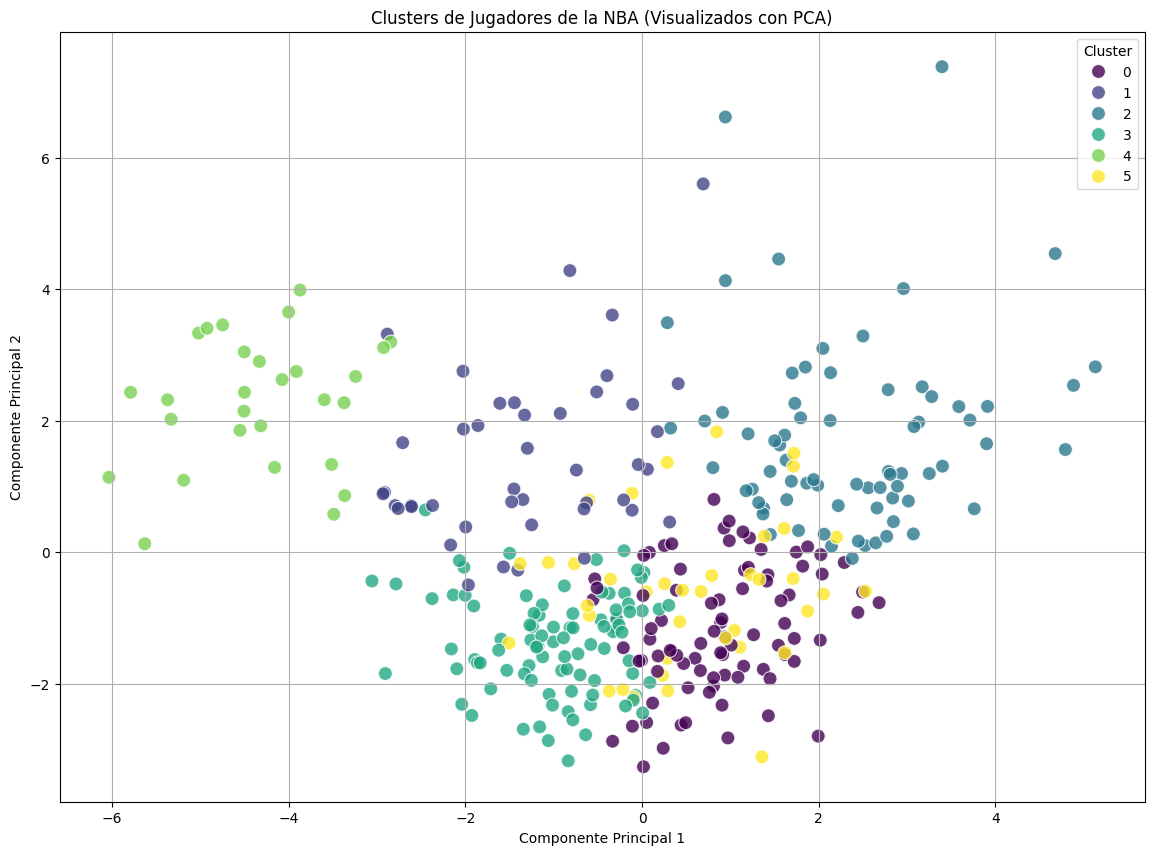


--- Cluster 0 ---
   PLAYER_NAME TEAM_ABBREVIATION
      AJ Green               MIL
 Aaron Holiday               HOU
 Aaron Nesmith               IND
    Alec Burks               NYK
Andrew Wiggins               GSW

--- Cluster 1 ---
  PLAYER_NAME TEAM_ABBREVIATION
 Aaron Gordon               DEN
Amen Thompson               HOU
Anthony Davis               LAL
  Bam Adebayo               MIA
 Bobby Portis               MIL

--- Cluster 2 ---
       PLAYER_NAME TEAM_ABBREVIATION
    Alperen Sengun               HOU
   Anfernee Simons               POR
   Anthony Edwards               MIN
     Austin Reaves               LAL
Bennedict Mathurin               IND

--- Cluster 3 ---
      PLAYER_NAME TEAM_ABBREVIATION
    Aaron Wiggins               OKC
       Al Horford               BOS
      Amir Coffey               LAC
Andre Jackson Jr.               MIL
    Anthony Black               ORL

--- Cluster 4 ---
    PLAYER_NAME TEAM_ABBREVIATION
 Andre Drummond               CHI
Bismack B

In [9]:
# 1.5: Visualización de Clusters con PCA
# Para visualizar los clusters en 2D, reduciremos la dimensionalidad de
# nuestros datos usando PCA (Análisis de Componentes Principales).

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['CLUSTER'] = clusters
pca_df['PLAYER_NAME'] = model_df['PLAYER_NAME']

plt.figure(figsize=(14, 10))
sns.scatterplot(x='PC1', y='PC2', hue='CLUSTER', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters de Jugadores de la NBA (Visualizados con PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Mostrar algunos jugadores de cada cluster
for i in range(optimal_k):
    print(f"\n--- Cluster {i} ---")
    print(model_df[model_df['CLUSTER'] == i][['PLAYER_NAME', 'TEAM_ABBREVIATION']].head(5).to_string(index=False))

Generación del joblib

In [10]:

import pandas as pd
import joblib
import sys
import os
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def generate_model(k: int):
    """
    Fetches player data, trains clustering models (KMeans, PCA), 
    and saves them to a joblib file.

    Args:
        k (int): The number of clusters for KMeans.
    """
    print(f"Iniciando la generación del modelo para k={k}...")

    # --- 1. Obtención de Datos ---
    try:
        print("Obteniendo estadísticas de jugadores de la temporada regular...")
        player_stats = leaguedashplayerstats.LeagueDashPlayerStats(
            season='2023-24', 
            season_type_all_star='Regular Season'
        ).get_data_frames()[0]
        print("Datos obtenidos correctamente.")
    except Exception as e:
        print(f"Error fatal al obtener los datos: {e}")
        sys.exit(1)

    # --- 2. Preprocesamiento de Datos ---
    print("Preprocesando los datos...")
    # Filtrar jugadores con al menos 500 minutos
    filtered_players = player_stats[player_stats['MIN'] >= 500].copy()

    # Seleccionar características y normalizar por 36 minutos
    stats_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 'TOV']
    
    model_df = filtered_players[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'MIN'] + stats_cols].copy()

    for col in stats_cols:
        if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']:
            model_df[col + '_PER36'] = (model_df[col] / model_df['MIN']) * 36

    model_df.fillna(0, inplace=True)

    features_per36 = [col + '_PER36' for col in stats_cols if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']]
    final_features = features_per36 + ['FG_PCT', 'FG3_PCT', 'FT_PCT']
    
    X = model_df[final_features]

    # --- 3. Entrenamiento de Modelos ---
    print("Entrenando los modelos (StandardScaler, KMeans, PCA)...")
    # Escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    pca.fit(X_scaled)

    # --- 4. Guardar Modelos en un archivo joblib ---
    model_filename = f"player_cluster_model_k{k}.joblib"
    model_payload = {
        'scaler': scaler,
        'kmeans': kmeans,
        'pca': pca,
        'features': final_features # Guardamos la lista de features para consistencia
    }
    
    joblib.dump(model_payload, model_filename)
    print(f"Modelos guardados exitosamente en '{model_filename}'")

generate_model(k=6)


Iniciando la generación del modelo para k=6...
Obteniendo estadísticas de jugadores de la temporada regular...
Datos obtenidos correctamente.
Preprocesando los datos...
Entrenando los modelos (StandardScaler, KMeans, PCA)...
Modelos guardados exitosamente en 'player_cluster_model_k6.joblib'


MlFlow

In [13]:
import joblib
import mlflow
import mlflow.sklearn

def log_model_to_mlflow():
    """
    Loads a scikit-learn model from a joblib file and logs it to MLflow.
    """
    # ruta del joblib
    model_filename = "player_cluster_model_k6.joblib"
    
    registered_model_name = "nba_player_cluster_k6"

    print(f"Loading model from {model_filename}...")
    try:
        model_payload = joblib.load(model_filename)
        kmeans_model = model_payload.get('kmeans')
        if kmeans_model is None:
            print("Error: 'kmeans' model not found in the joblib file.")
            return
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_filename}")
        return
    except Exception as e:
        print(f"An error occurred while loading the model: {e}")
        return

    print("Successfully loaded the KMeans model.")
    
    # Arrancar ml flow
    with mlflow.start_run() as run:
        print("Logging model to MLflow...")
        mlflow.sklearn.log_model(
            sk_model=kmeans_model,
            artifact_path="model",
            registered_model_name=registered_model_name
        )
        run_id = run.info.run_id
        print(f"Model successfully logged to MLflow with run_id: {run_id}")
        print(f"Model registered as: {registered_model_name}")

if __name__ == "__main__":
    log_model_to_mlflow()

Loading model from player_cluster_model_k6.joblib...
Successfully loaded the KMeans model.


2025/12/12 21:59:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/12 21:59:54 INFO mlflow.store.db.utils: Updating database tables
2025/12/12 21:59:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/12 21:59:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/12 21:59:54 INFO alembic.runtime.migration: Running 

Logging model to MLflow...


2025/12/12 22:00:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/12 22:00:01 INFO mlflow.store.db.utils: Updating database tables
2025/12/12 22:00:01 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/12 22:00:01 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Model successfully logged to MLflow with run_id: 43bcfb74a1eb43a59850887445b28831
Model registered as: nba_player_cluster_k6


Successfully registered model 'nba_player_cluster_k6'.
Created version '1' of model 'nba_player_cluster_k6'.


In [15]:
#nuevo modelo de mlflow completo

import pandas as pd
import mlflow
import mlflow.sklearn
import warnings
import sys
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Desactivar advertencias para una salida más limpia
warnings.simplefilter(action='ignore', category=FutureWarning)

def get_nba_data():
    """
    Obtiene y preprocesa los datos de estadísticas de jugadores de la NBA.
    """
    print("Obteniendo estadísticas de jugadores de la temporada regular 2023-24...")
    try:
        player_stats = leaguedashplayerstats.LeagueDashPlayerStats(
            season='2023-24',
            season_type_all_star='Regular Season'
        ).get_data_frames()[0]
        print("Datos obtenidos correctamente.")
    except Exception as e:
        print(f"Error fatal al obtener los datos de la API de la NBA: {e}")
        sys.exit(1)

    print("Preprocesando los datos...")
    filtered_players = player_stats[player_stats['MIN'] >= 500].copy()
    
    stats_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 'TOV']
    info_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'MIN']
    
    model_df = filtered_players[info_cols + stats_cols].copy()

    for col in stats_cols:
        if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']:
            model_df[f'{col}_PER36'] = (model_df[col] / model_df['MIN']) * 36

    model_df.fillna(0, inplace=True)

    features_per36 = [f'{col}_PER36' for col in stats_cols if col not in ['FG_PCT', 'FG3_PCT', 'FT_PCT']]
    final_features = features_per36 + ['FG_PCT', 'FG3_PCT', 'FT_PCT']
    
    return model_df, final_features

def log_elbow_method_metrics(X_scaled):
    """
    Calcula y registra la inercia para diferentes valores de k (método del codo).
    """
    print("Calculando y registrando métricas del método del codo...")
    k_range = range(2, 15)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertia = kmeans.inertia_
        mlflow.log_metric(f"inertia_k_{k}", inertia)
        print(f"  - Inercia para k={k}: {inertia:.2f}")

def log_full_model_to_mlflow():
    """
    Realiza el proceso completo de clustering y registra el modelo,
    métricas y artefactos en MLflow.
    """
    registered_model_name = "nba_player_cluster_k6"
    optimal_k = 6

    # Iniciar una ejecución de MLflow
    with mlflow.start_run() as run:
        print(f"Iniciada ejecución de MLflow con run_id: {run.info.run_id}")
        
        # 1. Obtener y procesar datos
        model_df, final_features = get_nba_data()
        X = model_df[final_features]
        
        # 2. Escalar datos
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 3. Registrar métricas del método del codo
        log_elbow_method_metrics(X_scaled)
        
        # 4. Entrenar y registrar el modelo final
        print(f"Entrenando modelo final con k={optimal_k}...")
        kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        clusters = kmeans_final.fit_predict(X_scaled)
        
        print("Registrando el modelo KMeans en MLflow...")
        mlflow.log_param("k", optimal_k)
        mlflow.sklearn.log_model(
            sk_model=kmeans_final,
            artifact_path="model",
            registered_model_name=registered_model_name
        )
        print(f"Modelo registrado como: {registered_model_name}")

        # 5. Generar y registrar artefacto de análisis de clusters
        print("Generando y registrando el artefacto de análisis de clusters...")
        model_df['CLUSTER'] = clusters
        cluster_analysis = model_df[final_features + ['CLUSTER']].groupby('CLUSTER').mean().round(2)
        
        # Guardar como CSV y registrar como artefacto
        cluster_analysis_path = "cluster_analysis.csv"
        cluster_analysis.to_csv(cluster_analysis_path)
        mlflow.log_artifact(cluster_analysis_path, "analysis")
        print(f"'{cluster_analysis_path}' guardado como artefacto en MLflow.")

        print("\n¡Proceso completado exitosamente!")

if __name__ == "__main__":
    log_full_model_to_mlflow()

Iniciada ejecución de MLflow con run_id: d03b46c51948431c8c0a6dec65d67a6e
Obteniendo estadísticas de jugadores de la temporada regular 2023-24...
Datos obtenidos correctamente.
Preprocesando los datos...
Calculando y registrando métricas del método del codo...
  - Inercia para k=2: 3381.86
  - Inercia para k=3: 2594.28
  - Inercia para k=4: 2373.54
  - Inercia para k=5: 2182.22
  - Inercia para k=6: 2042.69
  - Inercia para k=7: 1917.83
  - Inercia para k=8: 1842.69
  - Inercia para k=9: 1770.76
  - Inercia para k=10: 1714.23
  - Inercia para k=11: 1660.87
  - Inercia para k=12: 1593.33
  - Inercia para k=13: 1546.04
  - Inercia para k=14: 1507.03
Entrenando modelo final con k=6...


2025/12/13 03:09:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Registrando el modelo KMeans en MLflow...
Modelo registrado como: nba_player_cluster_k6
Generando y registrando el artefacto de análisis de clusters...
'cluster_analysis.csv' guardado como artefacto en MLflow.

¡Proceso completado exitosamente!


Registered model 'nba_player_cluster_k6' already exists. Creating a new version of this model...
Created version '3' of model 'nba_player_cluster_k6'.
